## Projeto: Processo de análise exploratória multivariada para a área de Marketing.

> O objetivo do projeto é explorar os dados e identificar fatores que ajudem a explicar porque o cliente aceita ou não uma campanha de Marketing e realiza a compra de determinados produtos.

In [505]:
!pip install -q -U watermark

In [506]:
# import sys

# !{sys.executable} -m pip install scikit-learn scipy pandas numpy matplotlib seaborn missingno


In [507]:
# Imports gerais
import sklearn
import scipy
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Estatística
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

# Machine Learning
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Utilidades
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [508]:
print("sklearn version:", sklearn.__version__)
print("scipy version:", scipy.__version__)
print("pandas version:", pd.__version__)


sklearn version: 1.7.2
scipy version: 1.15.3
pandas version: 2.3.3


### Carregando os Dados

In [509]:
# Carrega o dataset
df = pd.read_csv("dataset.csv")

In [510]:
# Shape
df.shape

(2237, 25)

In [511]:
# Amostra dos dados
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Web,Num_Compras_Catalogo,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6
0,9970,1977,Graduação,Casado,"$55,375.00",0,1,10/17/13,42,11,...,1,1,6,2,0,0,0,0,0,0
1,4002,1960,PhD,Casado,"$77,037.00",0,1,10/13/13,463,96,...,7,7,12,3,0,0,0,0,0,0
2,10914,1970,Graduação,Solteiro,"$24,163.00",1,1,2010-12-13,4,1,...,1,0,3,4,0,0,0,0,0,0
3,7279,1969,PhD,Casado,"$69,476.00",0,0,9/30/13,260,86,...,4,6,4,2,0,0,0,0,0,0
4,10582,1979,Graduação,Casado,"$72,063.00",0,1,2007-03-13,180,32,...,5,2,12,2,0,0,0,0,0,0


In [512]:
# Info
# df.info()

### Limpeza inicial dos dados

In [513]:
# Remover o espaço extra nos títulos das colunas
df.columns = df.columns.str.replace(' ', '') 

In [514]:
# A variável Renda tem o caracter $. Vamos remover esse caracter especial para ter a coluna como numérica
df['Renda'] = df['Renda'].str.replace('$', '').str.replace(',', '').astype(float) 

In [515]:
# A coluna de data está como tipo object. Vamos converter para o tipo datetime
df['Data_Cadastro_Cliente'] = pd.to_datetime(df['Data_Cadastro_Cliente']) 

In [516]:
# Info
# df.info()

In [517]:
# Amostra dos dados
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Web,Num_Compras_Catalogo,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,1,1,6,2,0,0,0,0,0,0
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,7,7,12,3,0,0,0,0,0,0
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,1,0,3,4,0,0,0,0,0,0
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,4,6,4,2,0,0,0,0,0,0
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,5,2,12,2,0,0,0,0,0,0


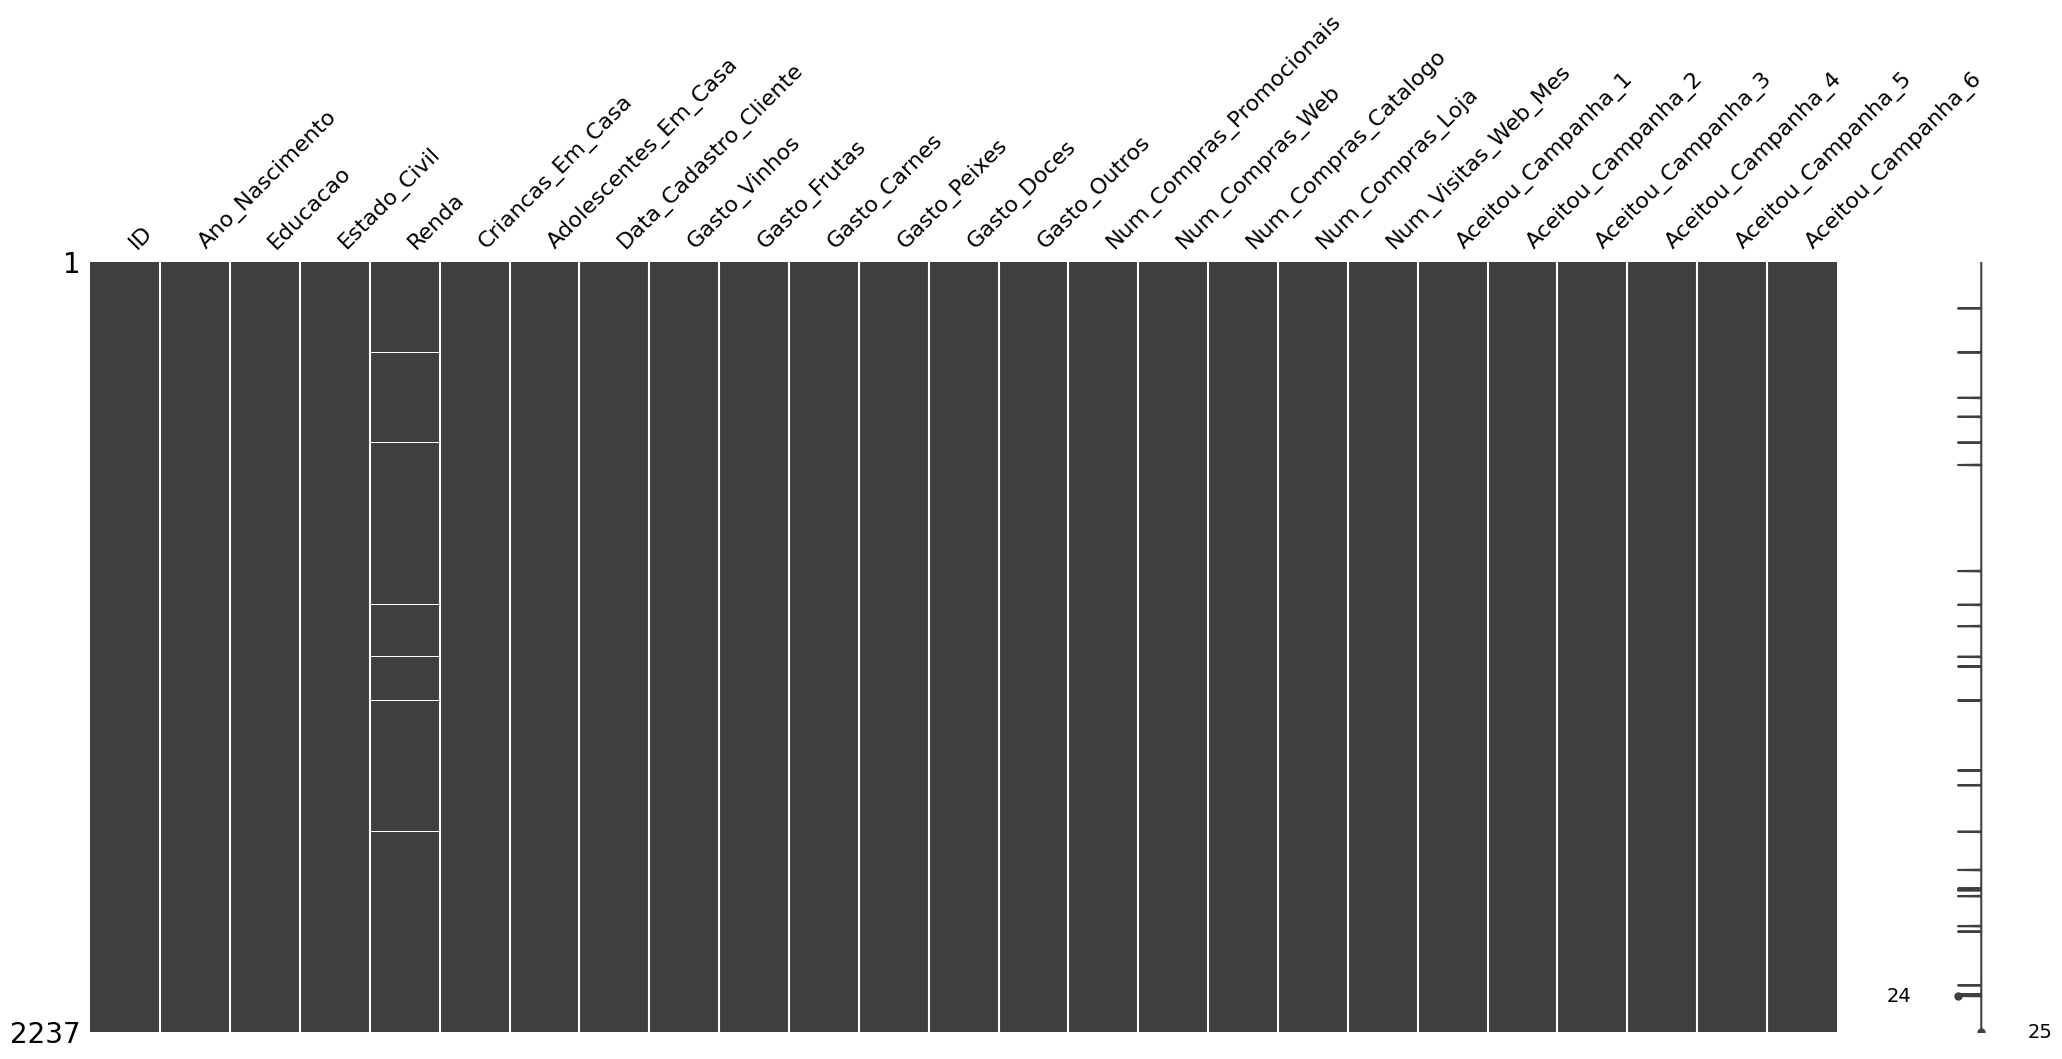

In [518]:
# Matriz de valores ausentes
msno.matrix(df)
plt.show()

> Os espaços em branco, indicam em qual coluna exatamente possui valores ausentes.

In [519]:
# Somar os valores ausentes
valores_ausentes = df.isnull().sum().sort_values(ascending = False)

In [520]:
valores_ausentes

Renda                       24
ID                           0
Ano_Nascimento               0
Educacao                     0
Estado_Civil                 0
Criancas_Em_Casa             0
Adolescentes_Em_Casa         0
Data_Cadastro_Cliente        0
Gasto_Vinhos                 0
Gasto_Frutas                 0
Gasto_Carnes                 0
Gasto_Peixes                 0
Gasto_Doces                  0
Gasto_Outros                 0
Num_Compras_Promocionais     0
Num_Compras_Web              0
Num_Compras_Catalogo         0
Num_Compras_Loja             0
Num_Visitas_Web_Mes          0
Aceitou_Campanha_1           0
Aceitou_Campanha_2           0
Aceitou_Campanha_3           0
Aceitou_Campanha_4           0
Aceitou_Campanha_5           0
Aceitou_Campanha_6           0
dtype: int64

In [521]:
# Filtrar pelos valores que são diferentes de zero
print(valores_ausentes.loc[valores_ausentes != 0])

Renda    24
dtype: int64


>Para tratar os valores ausentes primeiro devemos checar se há outliers na variável, o que ajudará a tomar a decisão ideal de tratamento dos valores ausentes.

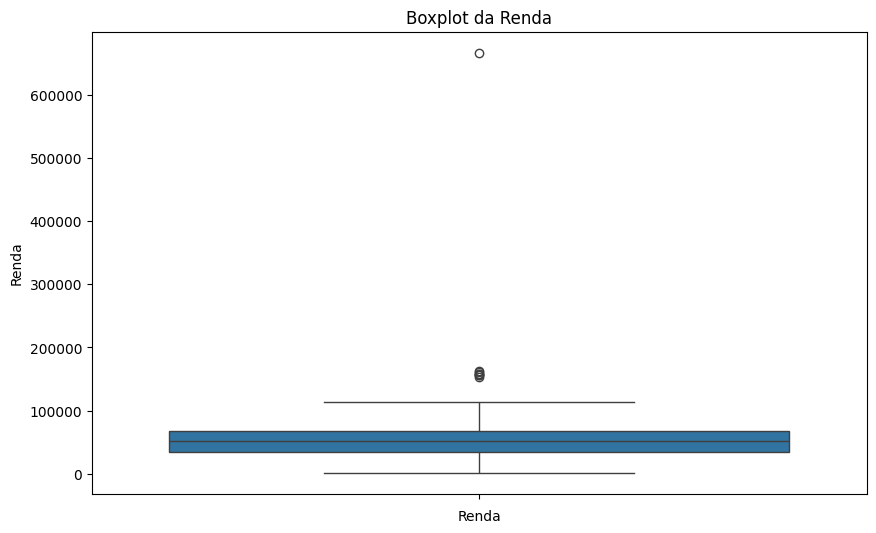

In [522]:
# Usar um boxplot para visualizar se há outliers na coluna 'Renda'
plt.figure(figsize = (10, 6))
sns.boxplot(df['Renda'])
plt.title('Boxplot da Renda')
plt.xlabel('Renda')
plt.show()

>Parece haver outliers

In [523]:
# Calcular o IQR para a coluna 'Renda'
Q1 = df['Renda'].quantile(0.25)
Q3 = df['Renda'].quantile(0.75)
IQR = Q3 - Q1

In [524]:
# Definir os limites para considerar um ponto como outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [525]:
# Identificar os outliers
outliers = df[(df['Renda'] < lower_bound) | (df['Renda'] > upper_bound)]
outliers

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Web,Num_Compras_Catalogo,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6
325,4931,1977,Graduação,Casado,157146.0,0,0,2013-04-29,1,0,...,0,28,0,1,0,0,0,0,0,0
497,1501,1982,PhD,Casado,160803.0,0,0,2008-04-12,55,16,...,0,28,1,0,0,0,0,0,0,0
526,9432,1977,Graduação,Casado,666666.0,1,0,2006-02-13,9,14,...,3,1,3,6,0,0,0,0,0,0
730,1503,1976,PhD,Casado,162397.0,1,1,2006-03-13,85,1,...,0,0,1,1,0,0,0,0,0,0
851,5336,1971,Mestrado,Casado,157733.0,1,0,2006-04-13,39,1,...,1,0,1,1,0,0,0,0,0,0
1787,5555,1975,Graduação,Divorciado,153924.0,0,0,2002-07-14,1,1,...,0,0,0,0,0,0,0,0,0,0
1886,11181,1949,PhD,Casado,156924.0,0,0,2013-08-29,2,1,...,0,0,0,0,0,0,0,0,0,0
2165,8475,1973,PhD,Casado,157243.0,0,1,2003-01-14,20,2,...,0,22,0,0,0,0,0,0,0,0


>Checar a distribuição da variável.

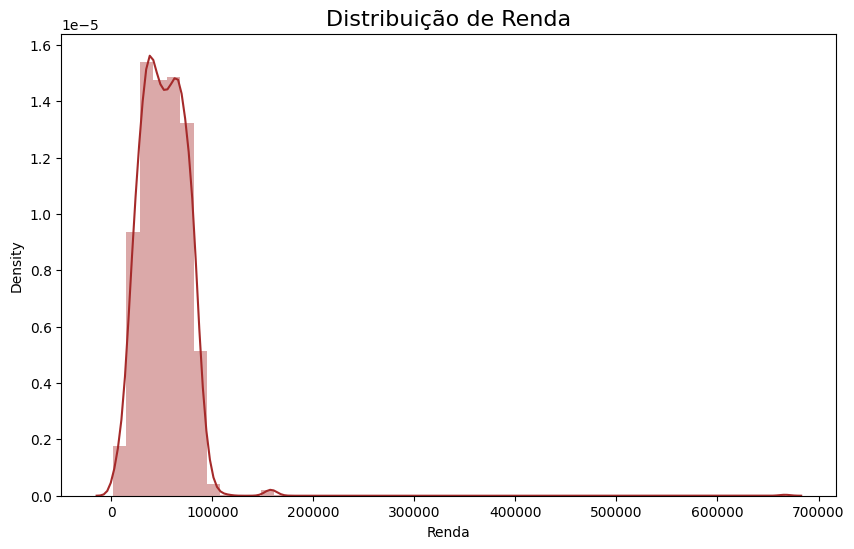

In [526]:
# Definindo o tamanho da figura
plt.figure(figsize = (10, 6)) 

# Criando o gráfico de distribuição
sns.distplot(df['Renda'], color = 'brown')  

# Definindo o título
plt.title('Distribuição de Renda', size = 16)  

# Exibindo o gráfico
plt.show()

In [527]:
# Filtrar o dataframe e removendo os outliers
df = df[(df['Renda'] >= lower_bound) & (df['Renda'] <= upper_bound)]

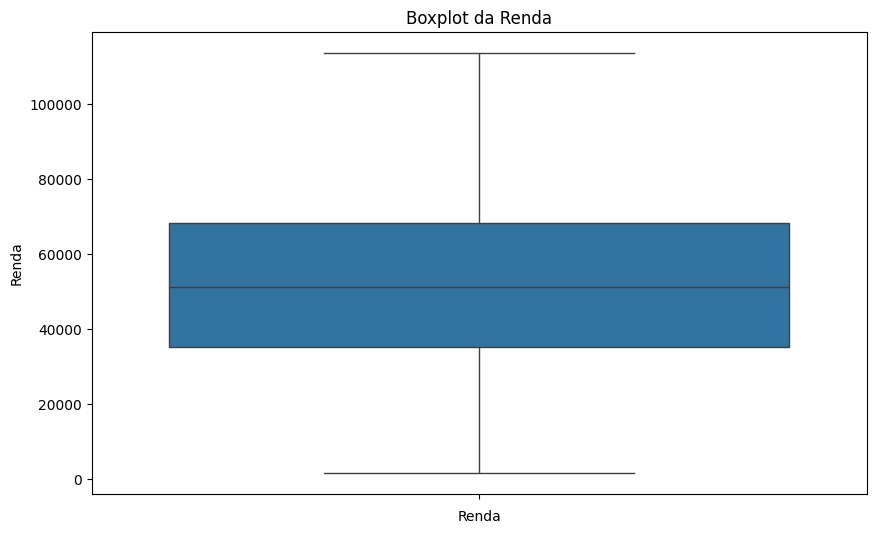

In [528]:
# Plotar um boxplot para visualizar se há outliers na coluna 'Renda'
plt.figure(figsize = (10, 6))
sns.boxplot(df['Renda'])
plt.title('Boxplot da Renda')
plt.xlabel('Renda')
plt.show()

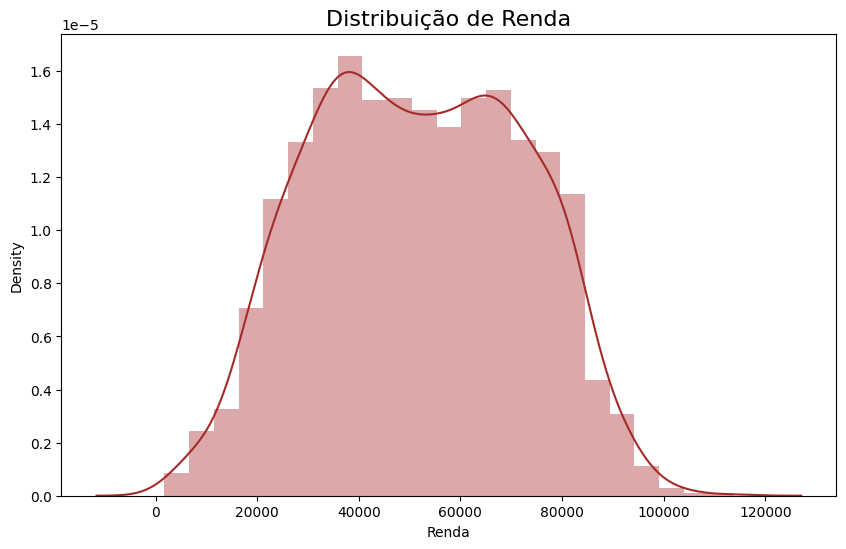

In [529]:
# Definir o tamanho da figura
plt.figure(figsize = (10, 6)) 

# Criar o o gráfico de distribuição
sns.distplot(df['Renda'], color = 'brown')  

# Definir o título
plt.title('Distribuição de Renda', size = 16)  

# Exibir o gráfico
plt.show()

>Tratar os valores ausentes.

In [530]:
# Normalizar os dados antes de aplicar o KNNImputer 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[['Renda']])

In [531]:
# Criar o KNNImputer
imputer = KNNImputer(n_neighbors=5)

In [532]:
# Imputar os valores ausentes com o imputer
data_imputed = imputer.fit_transform(data_scaled)

In [533]:
# Converter de volta para o formato original 
df['Renda'] = scaler.inverse_transform(data_imputed)

In [534]:
print('Total de Valores Ausentes:', df.isnull().sum().sum())

Total de Valores Ausentes: 0


In [535]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Web,Num_Compras_Catalogo,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,1,1,6,2,0,0,0,0,0,0
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,7,7,12,3,0,0,0,0,0,0
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,1,0,3,4,0,0,0,0,0,0
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,4,6,4,2,0,0,0,0,0,0
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,5,2,12,2,0,0,0,0,0,0


### Análise Exploratória 

In [536]:
# Colunas
df.columns

Index(['ID', 'Ano_Nascimento', 'Educacao', 'Estado_Civil', 'Renda',
       'Criancas_Em_Casa', 'Adolescentes_Em_Casa', 'Data_Cadastro_Cliente',
       'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Peixes',
       'Gasto_Doces', 'Gasto_Outros', 'Num_Compras_Promocionais',
       'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja',
       'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1', 'Aceitou_Campanha_2',
       'Aceitou_Campanha_3', 'Aceitou_Campanha_4', 'Aceitou_Campanha_5',
       'Aceitou_Campanha_6'],
      dtype='object')

In [537]:
# Drop (em memória) das colunas categóricas para criar o box plot das colunas quantitativas
data_boxplot = df.drop(columns = ['ID',
                                      'Educacao',
                                      'Estado_Civil',
                                      'Criancas_Em_Casa',
                                      'Data_Cadastro_Cliente',
                                      'Adolescentes_Em_Casa', 
                                      'Aceitou_Campanha_1', 
                                      'Aceitou_Campanha_2',
                                      'Aceitou_Campanha_3', 
                                      'Aceitou_Campanha_4', 
                                      'Aceitou_Campanha_5',
                                      'Aceitou_Campanha_6'])

In [538]:
data_boxplot.columns

Index(['Ano_Nascimento', 'Renda', 'Gasto_Vinhos', 'Gasto_Frutas',
       'Gasto_Carnes', 'Gasto_Peixes', 'Gasto_Doces', 'Gasto_Outros',
       'Num_Compras_Promocionais', 'Num_Compras_Web', 'Num_Compras_Catalogo',
       'Num_Compras_Loja', 'Num_Visitas_Web_Mes'],
      dtype='object')

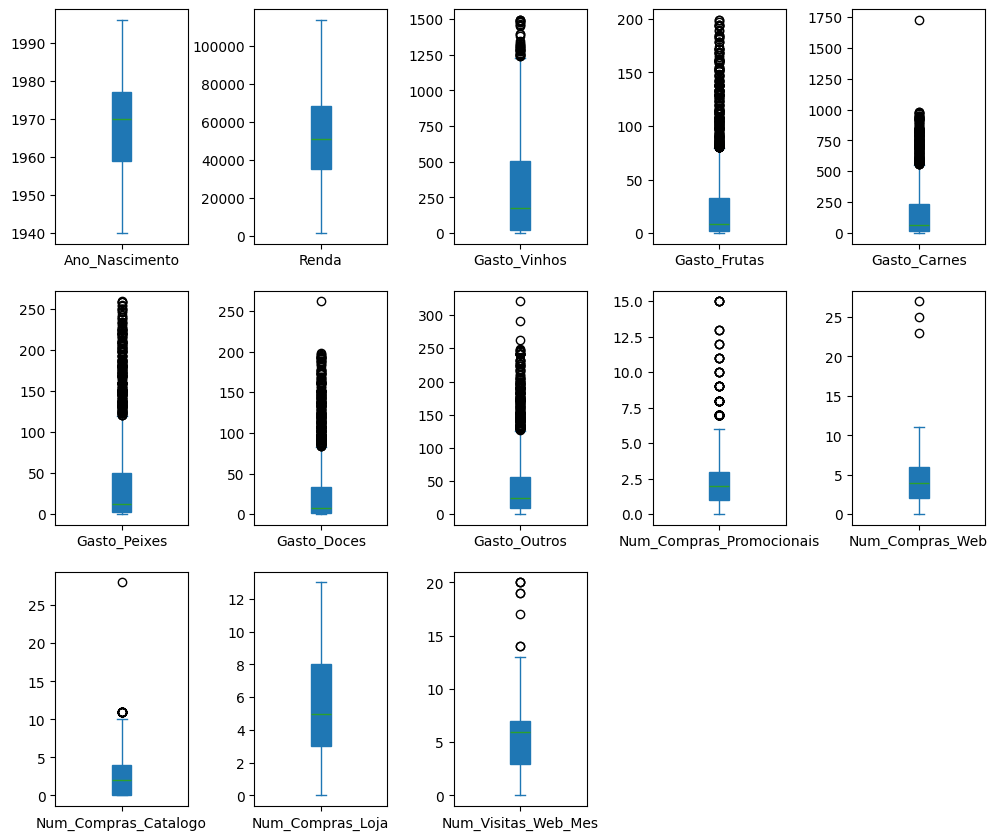

In [539]:
# Plot
data_boxplot.plot(subplots = True, layout = (4,5), kind = 'box', figsize = (12,14), patch_artist = True)
plt.subplots_adjust(wspace=0.5);

### Pré-processamento dos dados

In [540]:
# Criar uma nova coluna com a idade de cada cliente (ano atual - ano de nascimento)
ano_atual = datetime.now().year
df['Idade'] = ano_atual - df['Ano_Nascimento']

In [541]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Catalogo,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,1,6,2,0,0,0,0,0,0,49
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,7,12,3,0,0,0,0,0,0,66
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,0,3,4,0,0,0,0,0,0,56
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,6,4,2,0,0,0,0,0,0,57
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,2,12,2,0,0,0,0,0,0,47


In [542]:
# Criar uma coluna com o número de dias como cliente desde a data de cadastro
df['Dias_Como_Cliente'] = df['Data_Cadastro_Cliente'].max() - df['Data_Cadastro_Cliente']

In [543]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,6,2,0,0,0,0,0,0,49,255 days
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,12,3,0,0,0,0,0,0,66,259 days
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,3,4,0,0,0,0,0,0,56,1294 days
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,4,2,0,0,0,0,0,0,57,272 days
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,12,2,0,0,0,0,0,0,47,2665 days


In [544]:
# Remover a palavra "days" ao final do valor de cada linha da coluna Dias_Como_Cliente
df['Dias_Como_Cliente'] = df['Dias_Como_Cliente'].astype(str).str.replace(' days', '')

In [545]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,6,2,0,0,0,0,0,0,49,255
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,12,3,0,0,0,0,0,0,66,259
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,3,4,0,0,0,0,0,0,56,1294
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,4,2,0,0,0,0,0,0,57,272
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,12,2,0,0,0,0,0,0,47,2665


In [546]:
# df.info()

In [547]:
# Ajustar o tipo de dado da variável Dias_Como_Cliente
df['Dias_Como_Cliente'] = pd.to_numeric(df['Dias_Como_Cliente'], downcast = 'integer')

In [548]:
df.columns

Index(['ID', 'Ano_Nascimento', 'Educacao', 'Estado_Civil', 'Renda',
       'Criancas_Em_Casa', 'Adolescentes_Em_Casa', 'Data_Cadastro_Cliente',
       'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Peixes',
       'Gasto_Doces', 'Gasto_Outros', 'Num_Compras_Promocionais',
       'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja',
       'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1', 'Aceitou_Campanha_2',
       'Aceitou_Campanha_3', 'Aceitou_Campanha_4', 'Aceitou_Campanha_5',
       'Aceitou_Campanha_6', 'Idade', 'Dias_Como_Cliente'],
      dtype='object')

In [549]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 2236
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        2205 non-null   int64         
 1   Ano_Nascimento            2205 non-null   int64         
 2   Educacao                  2205 non-null   object        
 3   Estado_Civil              2205 non-null   object        
 4   Renda                     2205 non-null   float64       
 5   Criancas_Em_Casa          2205 non-null   int64         
 6   Adolescentes_Em_Casa      2205 non-null   int64         
 7   Data_Cadastro_Cliente     2205 non-null   datetime64[ns]
 8   Gasto_Vinhos              2205 non-null   int64         
 9   Gasto_Frutas              2205 non-null   int64         
 10  Gasto_Carnes              2205 non-null   int64         
 11  Gasto_Peixes              2205 non-null   int64         
 12  Gasto_Doces              

In [550]:
# Criar uma variável com o Total de Compras realizadas nos 3 diferentes canais
df['TotalCompras'] = df['Num_Compras_Web'] + df['Num_Compras_Catalogo'] + df['Num_Compras_Loja']

In [551]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,2,0,0,0,0,0,0,49,255,8
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,3,0,0,0,0,0,0,66,259,26
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,4,0,0,0,0,0,0,56,1294,4
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,2,0,0,0,0,0,0,57,272,14
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,2,0,0,0,0,0,0,47,2665,19


In [552]:
df.columns

Index(['ID', 'Ano_Nascimento', 'Educacao', 'Estado_Civil', 'Renda',
       'Criancas_Em_Casa', 'Adolescentes_Em_Casa', 'Data_Cadastro_Cliente',
       'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Peixes',
       'Gasto_Doces', 'Gasto_Outros', 'Num_Compras_Promocionais',
       'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja',
       'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1', 'Aceitou_Campanha_2',
       'Aceitou_Campanha_3', 'Aceitou_Campanha_4', 'Aceitou_Campanha_5',
       'Aceitou_Campanha_6', 'Idade', 'Dias_Como_Cliente', 'TotalCompras'],
      dtype='object')

In [553]:
# Criar a variável Gasto_Total com o somatório de todas as colunas que começam com o nome Gasto
df['Gasto_Total'] = df.filter(like = 'Gasto').sum(axis=1)

In [554]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,0,0,0,0,0,0,49,255,8,162
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,0,0,0,0,0,0,66,259,26,1123
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,0,0,0,0,0,0,56,1294,4,17
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,0,0,0,0,0,0,57,272,14,1044
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,0,0,0,0,0,0,47,2665,19,758


In [555]:
df.columns

Index(['ID', 'Ano_Nascimento', 'Educacao', 'Estado_Civil', 'Renda',
       'Criancas_Em_Casa', 'Adolescentes_Em_Casa', 'Data_Cadastro_Cliente',
       'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Peixes',
       'Gasto_Doces', 'Gasto_Outros', 'Num_Compras_Promocionais',
       'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja',
       'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1', 'Aceitou_Campanha_2',
       'Aceitou_Campanha_3', 'Aceitou_Campanha_4', 'Aceitou_Campanha_5',
       'Aceitou_Campanha_6', 'Idade', 'Dias_Como_Cliente', 'TotalCompras',
       'Gasto_Total'],
      dtype='object')

In [556]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 2236
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        2205 non-null   int64         
 1   Ano_Nascimento            2205 non-null   int64         
 2   Educacao                  2205 non-null   object        
 3   Estado_Civil              2205 non-null   object        
 4   Renda                     2205 non-null   float64       
 5   Criancas_Em_Casa          2205 non-null   int64         
 6   Adolescentes_Em_Casa      2205 non-null   int64         
 7   Data_Cadastro_Cliente     2205 non-null   datetime64[ns]
 8   Gasto_Vinhos              2205 non-null   int64         
 9   Gasto_Frutas              2205 non-null   int64         
 10  Gasto_Carnes              2205 non-null   int64         
 11  Gasto_Peixes              2205 non-null   int64         
 12  Gasto_Doces              

In [557]:
df['Aceitou_Campanha_1'].value_counts()

Aceitou_Campanha_1
0    2042
1     163
Name: count, dtype: int64

In [558]:
df['Aceitou_Campanha_2'].value_counts()

Aceitou_Campanha_2
0    2041
1     164
Name: count, dtype: int64

In [559]:
# Criar a variável para indicar se o cliente aceitou qualquer campanha (e comprou o produto ofertado)
df['aceite_campanha'] = df.filter(like = 'Aceitou').sum(axis = 1)

In [560]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,aceite_campanha
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,0,0,0,0,0,49,255,8,162,0
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,0,0,0,0,0,66,259,26,1123,0
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,0,0,0,0,0,56,1294,4,17,0
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,0,0,0,0,0,57,272,14,1044,0
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,0,0,0,0,0,47,2665,19,758,0


In [561]:
df.sample(10)

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,aceite_campanha
199,5682,1953,PhD,Solteiro,64108.0,0,1,2013-03-23,948,10,...,0,0,0,0,0,73,463,26,1099,0
1760,7683,1968,Mestrado,Casado,70777.0,0,1,2014-02-25,554,35,...,0,0,0,0,0,58,124,20,787,0
7,6379,1949,Mestrado,Viúvo,47570.0,1,1,2013-05-29,67,1,...,0,0,0,0,1,77,396,6,121,1
1406,2730,1955,Graduação,Solteiro,80317.0,0,0,2013-08-20,536,11,...,0,0,0,0,0,71,313,17,1231,0
1244,9964,1979,Graduação,Solteiro,61825.0,0,1,2008-07-13,162,50,...,0,0,0,0,0,47,2177,14,424,0
1077,1272,1965,Mestrado,Solteiro,55250.0,0,1,2012-10-21,664,58,...,0,0,0,0,0,61,616,22,903,0
143,9256,1971,Graduação,Solteiro,58350.0,0,1,2001-04-13,493,26,...,0,0,0,0,0,55,4825,23,1001,0
1997,8867,1988,PhD,Casado,67546.0,0,0,2012-08-31,864,134,...,0,0,0,0,0,38,667,19,2126,0
913,10207,1978,Graduação,Casado,22775.0,1,0,2013-06-19,5,1,...,0,0,0,0,0,48,375,3,15,0
781,10617,1989,Mestrado,Divorciado,10979.0,0,0,2014-05-22,8,4,...,0,0,0,0,0,37,38,6,30,0


In [562]:
# Ajustar o tipo de dado e colocar em uma nova coluna
df['RespostaCampanha'] = df['aceite_campanha'].apply(lambda x: 'Aceitou' if x > 0 else 'Não Aceitou')

In [563]:
df.head()

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,aceite_campanha,RespostaCampanha
0,9970,1977,Graduação,Casado,55375.0,0,1,2013-10-17,42,11,...,0,0,0,0,49,255,8,162,0,Não Aceitou
1,4002,1960,PhD,Casado,77037.0,0,1,2013-10-13,463,96,...,0,0,0,0,66,259,26,1123,0,Não Aceitou
2,10914,1970,Graduação,Solteiro,24163.0,1,1,2010-12-13,4,1,...,0,0,0,0,56,1294,4,17,0,Não Aceitou
3,7279,1969,PhD,Casado,69476.0,0,0,2013-09-30,260,86,...,0,0,0,0,57,272,14,1044,0,Não Aceitou
4,10582,1979,Graduação,Casado,72063.0,0,1,2007-03-13,180,32,...,0,0,0,0,47,2665,19,758,0,Não Aceitou


In [564]:
df.sample(10)

,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,aceite_campanha,RespostaCampanha
1814,2125,1959,Graduação,Divorciado,63033.0,0,0,2013-11-15,194,61,...,0,0,0,0,67,226,15,1102,0,Não Aceitou
1313,8969,1977,Graduação,Casado,71855.0,0,1,2013-01-16,548,31,...,0,0,0,0,49,529,21,1141,0,Não Aceitou
93,10286,1962,Graduação,Casado,83715.0,0,0,2002-03-14,318,8,...,0,0,0,0,64,4490,23,926,0,Não Aceitou
220,3376,1970,Mestrado,Divorciado,55282.0,1,0,2013-12-13,125,6,...,0,0,0,0,56,198,10,235,0,Não Aceitou
594,10432,1974,Graduação,Divorciado,19346.0,1,0,2014-01-30,2,0,...,0,0,0,0,52,150,4,22,0,Não Aceitou
1770,3945,1947,PhD,Viúvo,68117.0,0,1,2003-10-13,618,44,...,0,0,0,1,79,3912,23,930,2,Aceitou
373,10779,1983,Graduação,Solteiro,22148.0,0,0,2014-04-13,15,5,...,0,0,0,0,43,77,4,49,0,Não Aceitou
32,7685,1978,Graduação,Casado,33039.0,1,0,2009-09-13,30,8,...,0,0,0,0,48,1750,6,78,0,Não Aceitou
829,4418,1983,Mestrado,Solteiro,89616.0,0,0,2013-02-25,671,47,...,0,0,0,1,43,489,24,1644,1,Aceitou
330,5302,1986,Graduação,Casado,78394.0,0,0,2013-02-15,298,27,...,0,0,0,1,40,499,15,1428,1,Aceitou


In [565]:
# Observar uma amostra aleatória das variáveis criadas
df[['Idade', 'Dias_Como_Cliente', 'TotalCompras', 'Gasto_Total', 'RespostaCampanha']].sample(10)

,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,RespostaCampanha
534,60,839,19,1477,Não Aceitou
308,46,2147,15,1754,Aceitou
1137,35,60,3,14,Não Aceitou
1436,83,313,13,900,Não Aceitou
1942,55,624,8,180,Aceitou
1710,59,669,21,1148,Não Aceitou
1512,41,1509,20,968,Não Aceitou
598,40,2390,3,18,Não Aceitou
960,69,593,18,1336,Aceitou
1055,51,3119,17,641,Não Aceitou


In [566]:
# Não vou precisar mais destas variáveis
df.drop(['Ano_Nascimento', 'Data_Cadastro_Cliente', 'aceite_campanha'], axis = 1, inplace = True)

In [567]:
df.head()

,ID,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,...,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,RespostaCampanha
0,9970,Graduação,Casado,55375.0,0,1,42,11,57,10,...,0,0,0,0,0,49,255,8,162,Não Aceitou
1,4002,PhD,Casado,77037.0,0,1,463,96,333,168,...,0,0,0,0,0,66,259,26,1123,Não Aceitou
2,10914,Graduação,Solteiro,24163.0,1,1,4,1,7,2,...,0,0,0,0,0,56,1294,4,17,Não Aceitou
3,7279,PhD,Casado,69476.0,0,0,260,86,559,63,...,0,0,0,0,0,57,272,14,1044,Não Aceitou
4,10582,Graduação,Casado,72063.0,0,1,180,32,348,76,...,0,0,0,0,0,47,2665,19,758,Não Aceitou


In [568]:
df.describe()

,ID,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,Gasto_Doces,Gasto_Outros,...,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000,2205.000000,2205.000000,2205.000000,2205.000000
mean,5585.439456,51622.094785,0.442177,0.506576,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.073923,0.074376,0.073016,0.064399,0.013605,0.15102,57.095692,1307.092971,12.569615,606.821769
std,3247.546423,20713.063826,0.537132,0.544380,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.261705,0.262442,0.260222,0.245518,0.115872,0.35815,11.705801,1429.824606,7.180350,601.675284
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,30.000000,0.000000,0.000000,5.000000
25%,2815.000000,35196.000000,0.000000,0.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,49.000000,286.000000,6.000000,69.000000
50%,5455.000000,51287.000000,0.000000,0.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,56.000000,583.000000,12.000000,397.000000
75%,8418.000000,68281.000000,1.000000,1.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,67.000000,2116.000000,18.000000,1047.000000
max,11191.000000,113734.000000,2.000000,2.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,86.000000,4915.000000,32.000000,2525.000000


### Extraindo Insights com Análise Multivariada

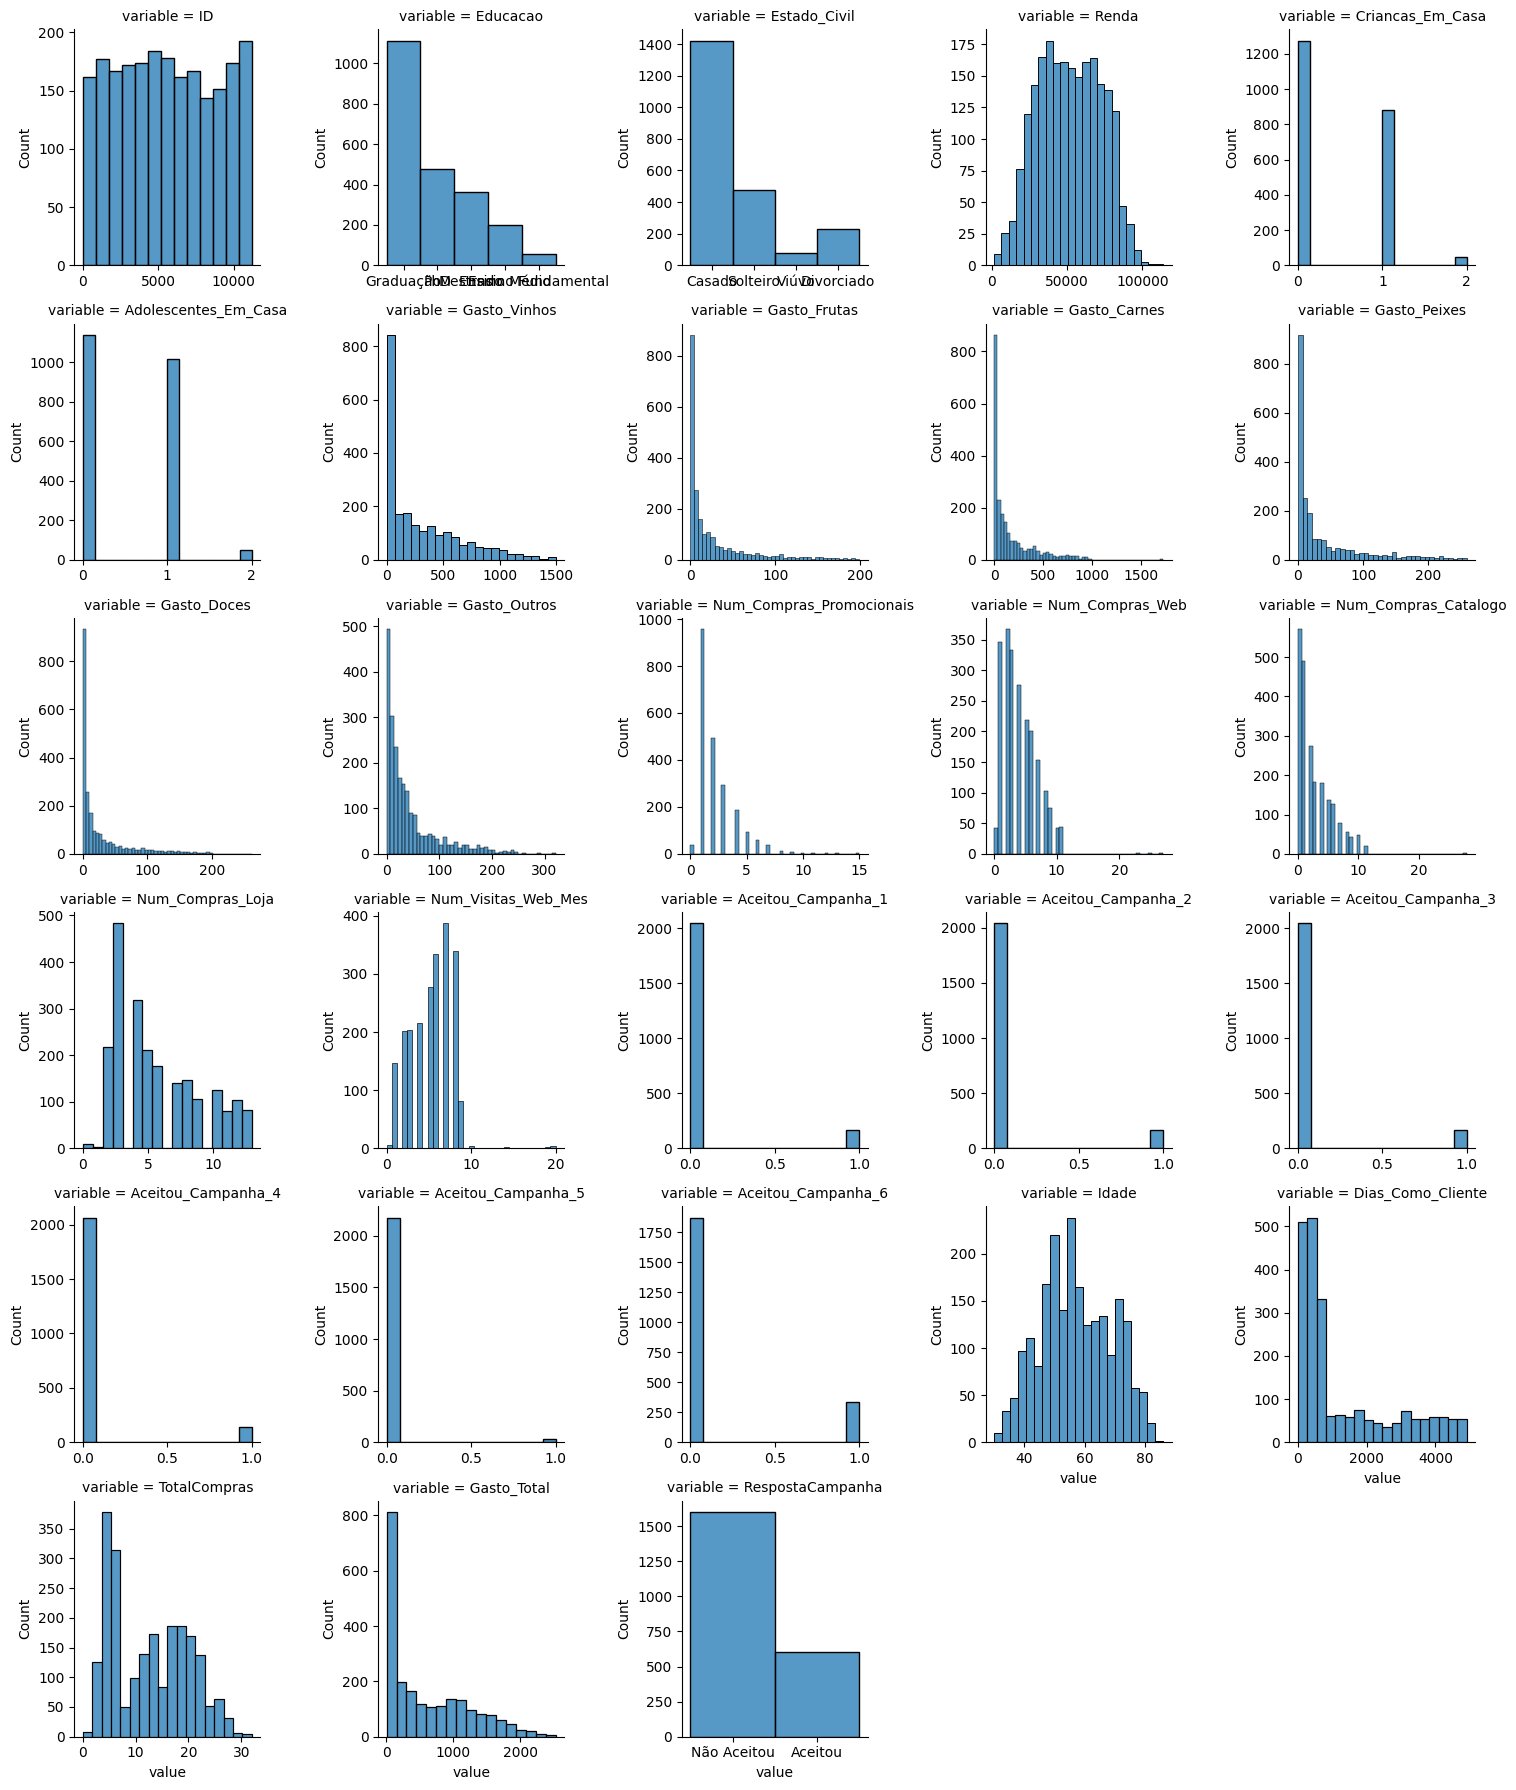

In [569]:
# Distribuição das Variáveis
hist = pd.melt(df, value_vars = df )
hist = sns.FacetGrid (hist, col = 'variable', col_wrap = 5, sharex = False, sharey = False)
hist.map(sns.histplot, 'value')

### Qual a Proporção de Clientes Que Aceitaram/Não Aceitaram Campanha de Marketing?

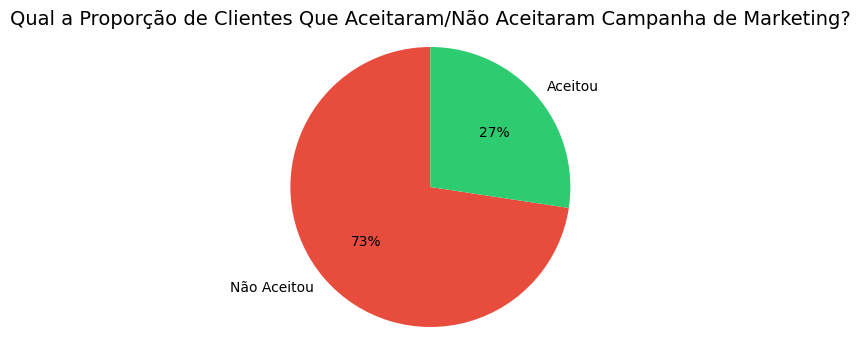

In [570]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tamanho da figura
fig, ax = plt.subplots(figsize=(6, 4))

# Conta as ocorrências de cada resposta
counts = df['RespostaCampanha'].value_counts()
labels = counts.index.tolist()

# Paleta verde e vermelha
colors = ["#E74C3C","#2ECC71"]  # verde, vermelho

# Pie chart
ax.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%.0f%%',
    startangle=90
)

# Título
ax.set_title(
    'Qual a Proporção de Clientes Que Aceitaram/Não Aceitaram Campanha de Marketing?',
    fontsize=14
)

# Mantém os eixos iguais
ax.axis('equal')

# Display
plt.show()


### Qual a Taxa de Sucesso de Cada Uma das 6 Campanhas?

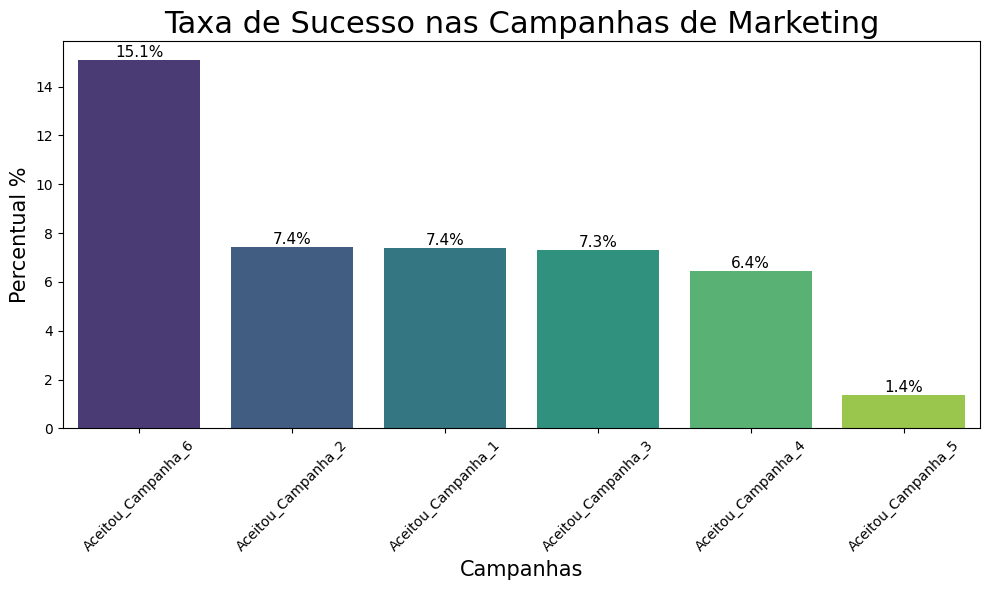

In [571]:
# Lista de campanhas
Campanhas = ['Aceitou_Campanha_1', 
             'Aceitou_Campanha_2', 
             'Aceitou_Campanha_3', 
             'Aceitou_Campanha_4', 
             'Aceitou_Campanha_5', 
             'Aceitou_Campanha_6']

# Calcula o percentual
campaigns = (
    pd.DataFrame(df[Campanhas].mean() * 100, columns=['Percent'])
      .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='index',
    y='Percent',
    data=campaigns.sort_values('Percent', ascending=False),
    palette='viridis'   # 🎨 paleta aplicada aqui
)

# Labels
plt.xlabel('Campanhas', size=15)
plt.ylabel('Percentual %', size=15)
plt.title('Taxa de Sucesso nas Campanhas de Marketing', size=22)

# Inclui o percentual no gráfico
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

# Inclina os rótulos no eixo X
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Display
plt.tight_layout()
plt.show()



### A Idade Tem Influência nas Decisões de Gastos dos Clientes?

In [572]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 2236
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2205 non-null   int64  
 1   Educacao                  2205 non-null   object 
 2   Estado_Civil              2205 non-null   object 
 3   Renda                     2205 non-null   float64
 4   Criancas_Em_Casa          2205 non-null   int64  
 5   Adolescentes_Em_Casa      2205 non-null   int64  
 6   Gasto_Vinhos              2205 non-null   int64  
 7   Gasto_Frutas              2205 non-null   int64  
 8   Gasto_Carnes              2205 non-null   int64  
 9   Gasto_Peixes              2205 non-null   int64  
 10  Gasto_Doces               2205 non-null   int64  
 11  Gasto_Outros              2205 non-null   int64  
 12  Num_Compras_Promocionais  2205 non-null   int64  
 13  Num_Compras_Web           2205 non-null   int64  
 14  Num_Compras_C

In [573]:
# Filtra as colunas categóricas e calcula a correlação das colunas quantitativas
df_corr = df.drop(['ID',
                           'Educacao',
                           'Estado_Civil',
                           'Criancas_Em_Casa',
                           'Adolescentes_Em_Casa', 
                           'Aceitou_Campanha_1', 
                           'Aceitou_Campanha_2',
                           'Aceitou_Campanha_3', 
                           'Aceitou_Campanha_4', 
                           'Aceitou_Campanha_5',
                           'Aceitou_Campanha_6', 
                           'Educacao',
                           'RespostaCampanha'], axis = 1).corr()

In [574]:
column_corr = df_corr.loc['Idade']

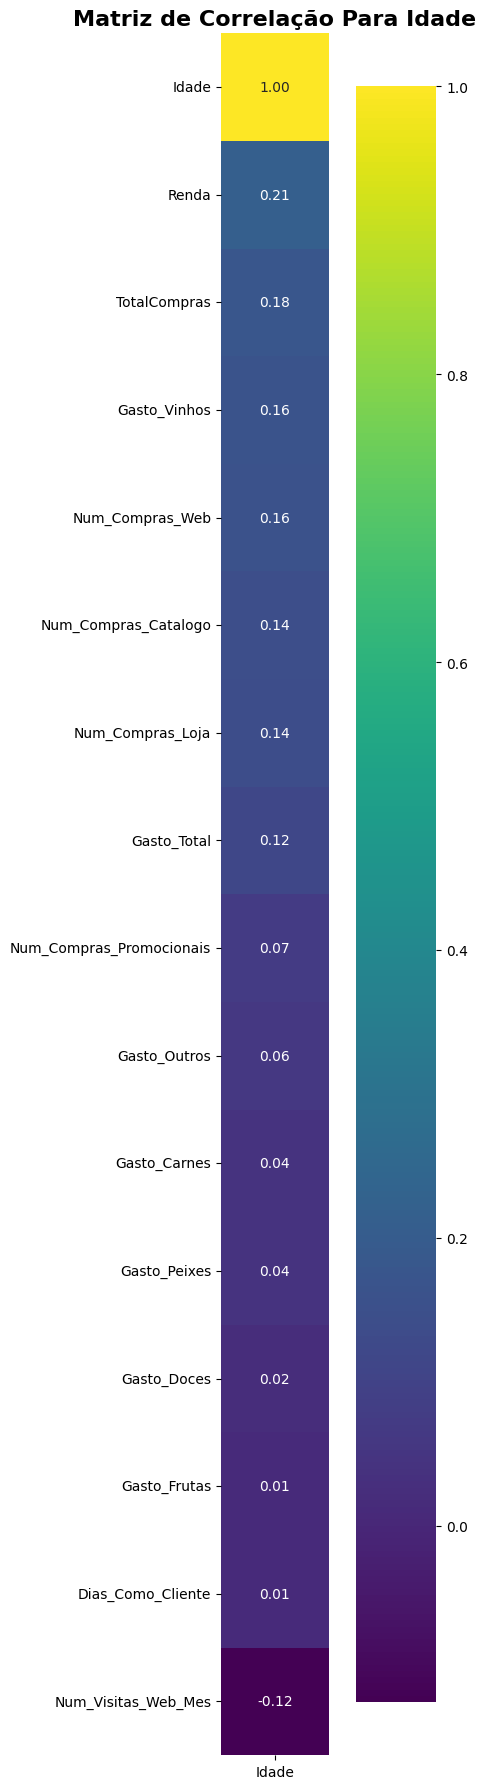

In [575]:
# Plot
plt.figure(figsize=(6, 18))
sns.heatmap(
    pd.DataFrame(column_corr.sort_values(ascending=False)),
    annot=True,
    cmap='viridis',  
    cbar=True,
    square=True,
    fmt='.2f'
)

plt.title('Matriz de Correlação Para Idade', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


### Qual a Relação Entre Gasto Total e Resposta às Campanhas de Marketing?

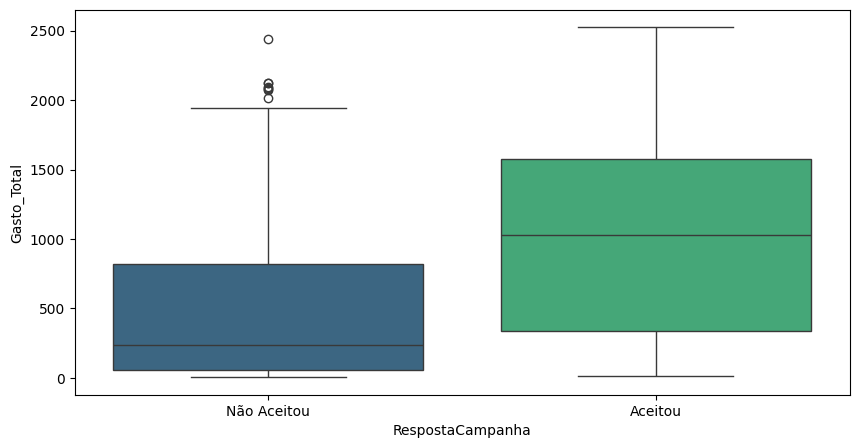

In [576]:
# Plot
plt.figure(figsize = (10,5))
sns.boxplot(x = 'RespostaCampanha', y = 'Gasto_Total', data = df, palette = 'viridis');

### Em Qual Categoria de Produto os Clientes Têm Maior Gasto?

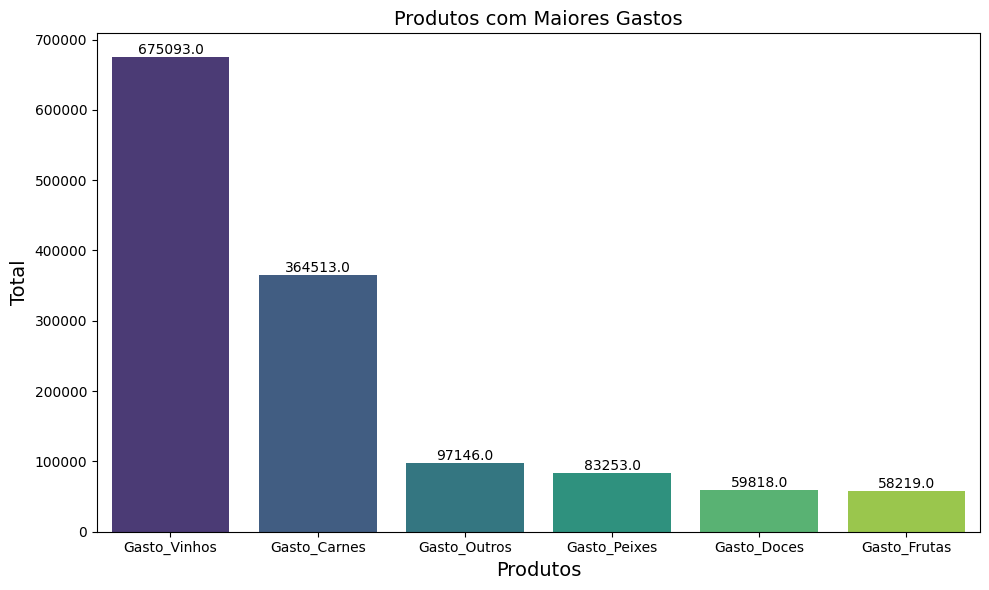

In [577]:
# Categorias de produtos
produtos = ['Gasto_Vinhos', 
            'Gasto_Frutas',
            'Gasto_Carnes', 
            'Gasto_Peixes',
            'Gasto_Doces',
            'Gasto_Outros']

# Cria o dataframe com os totais
df_produtos = pd.DataFrame(df[produtos].sum(), columns = ['Sum']).reset_index()

# Plot
plt.figure(figsize = (10, 6))
ax = sns.barplot(x = 'index', 
                 y = 'Sum', 
                 data = df_produtos.sort_values('Sum', ascending = False), 
                 palette = 'viridis')

# Labels
plt.xlabel('Produtos', size = 14)
plt.ylabel('Total', size = 14)
plt.title('Produtos com Maiores Gastos', size = 14)

# Inclui os valores no gráfico
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x() + p.get_width() / 2, p.get_height()), ha = 'center', va = 'bottom')

# Display 
plt.tight_layout()
plt.show()

### Qual a Relação Entre Gasto com Vinho e Resposta às Campanhas de Marketing?

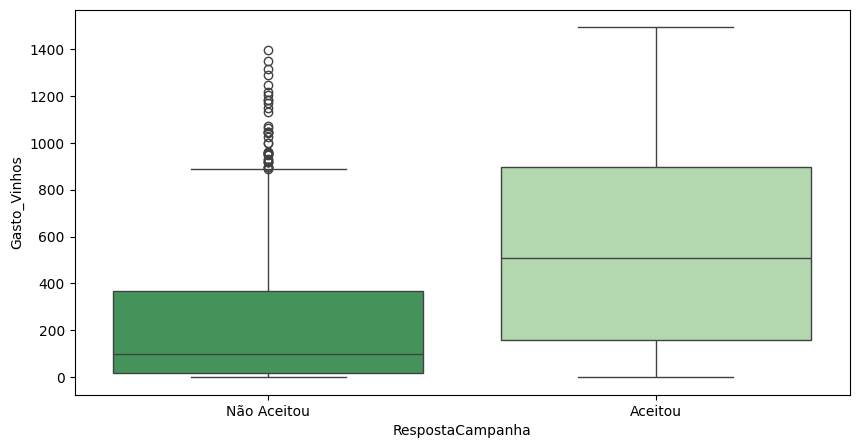

In [578]:
plt.figure(figsize = (10,5))
sns.boxplot(x = 'RespostaCampanha', y = 'Gasto_Vinhos', data = df, palette = 'Greens_r');

### Qual a Relação Entre Renda e Resposta às Campanhas de Marketing?

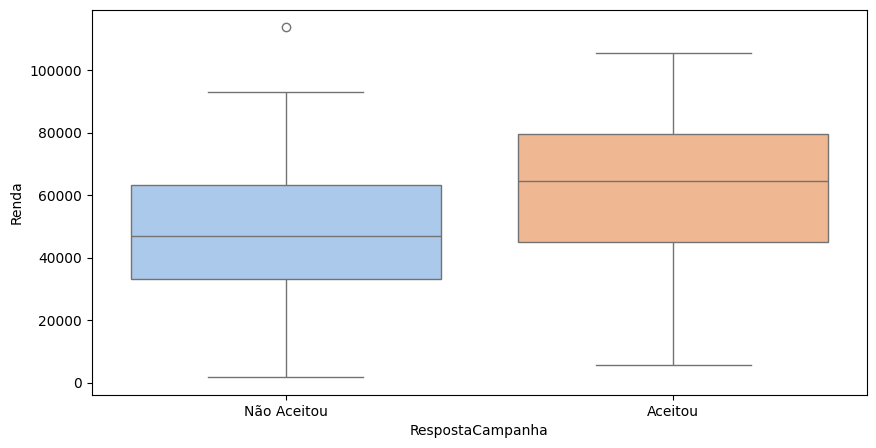

In [579]:
# Plot
plt.figure(figsize = (10,5))
sns.boxplot(x = 'RespostaCampanha', y = 'Renda', data = df, palette = 'pastel');

### Qual a Relação Entre Renda e Gasto Total?

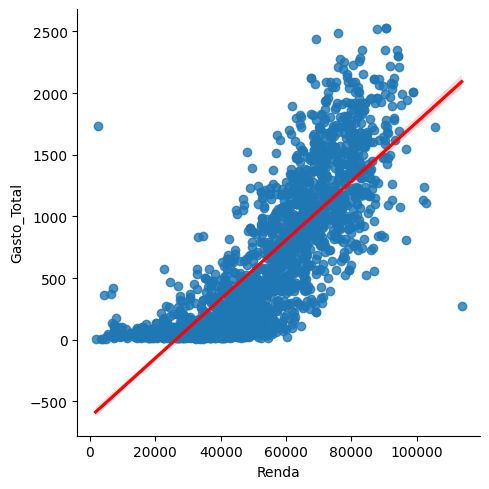

In [580]:
# Plot
sns.lmplot(x = 'Renda', y = 'Gasto_Total', data = df, palette = 'blue', line_kws = {'color': 'red'})

### Quais Fatores São Mais Importantes Para Explicar a Decisão do Cliente em Aceitar ou Não a Campanha?

In [581]:
df.head()

,ID,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,...,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,RespostaCampanha
0,9970,Graduação,Casado,55375.0,0,1,42,11,57,10,...,0,0,0,0,0,49,255,8,162,Não Aceitou
1,4002,PhD,Casado,77037.0,0,1,463,96,333,168,...,0,0,0,0,0,66,259,26,1123,Não Aceitou
2,10914,Graduação,Solteiro,24163.0,1,1,4,1,7,2,...,0,0,0,0,0,56,1294,4,17,Não Aceitou
3,7279,PhD,Casado,69476.0,0,0,260,86,559,63,...,0,0,0,0,0,57,272,14,1044,Não Aceitou
4,10582,Graduação,Casado,72063.0,0,1,180,32,348,76,...,0,0,0,0,0,47,2665,19,758,Não Aceitou


In [582]:
# Converte as variáveis do tipo texto em representação numérica usando One-Hot Encoding
df_imp = pd.get_dummies(df, columns = ['Educacao', 'Estado_Civil'])

In [583]:
df_imp.columns

Index(['ID', 'Renda', 'Criancas_Em_Casa', 'Adolescentes_Em_Casa',
       'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Peixes',
       'Gasto_Doces', 'Gasto_Outros', 'Num_Compras_Promocionais',
       'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja',
       'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1', 'Aceitou_Campanha_2',
       'Aceitou_Campanha_3', 'Aceitou_Campanha_4', 'Aceitou_Campanha_5',
       'Aceitou_Campanha_6', 'Idade', 'Dias_Como_Cliente', 'TotalCompras',
       'Gasto_Total', 'RespostaCampanha', 'Educacao_Ensino Fundamental',
       'Educacao_Ensino Médio', 'Educacao_Graduação', 'Educacao_Mestrado',
       'Educacao_PhD', 'Estado_Civil_Casado', 'Estado_Civil_Divorciado',
       'Estado_Civil_Solteiro', 'Estado_Civil_Viúvo'],
      dtype='object')

In [584]:
df_imp.head()

,ID,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,Gasto_Doces,Gasto_Outros,...,RespostaCampanha,Educacao_Ensino Fundamental,Educacao_Ensino Médio,Educacao_Graduação,Educacao_Mestrado,Educacao_PhD,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Solteiro,Estado_Civil_Viúvo
0,9970,55375.0,0,1,42,11,57,10,28,14,...,Não Aceitou,False,False,True,False,False,True,False,False,False
1,4002,77037.0,0,1,463,96,333,168,53,10,...,Não Aceitou,False,False,False,False,True,True,False,False,False
2,10914,24163.0,1,1,4,1,7,2,1,2,...,Não Aceitou,False,False,True,False,False,False,False,True,False
3,7279,69476.0,0,0,260,86,559,63,9,67,...,Não Aceitou,False,False,False,False,True,True,False,False,False
4,10582,72063.0,0,1,180,32,348,76,32,90,...,Não Aceitou,False,False,True,False,False,True,False,False,False


In [585]:
# Remover variáveis que seriam redundantes ou desnecessárias
# Criando X (dados de entrada) remover RespostaCampanha (dados de saída)
X = df_imp.drop(['ID',
                     'Gasto_Vinhos', 
                     'Gasto_Frutas', 
                     'Gasto_Carnes', 
                     'Gasto_Peixes',
                     'Gasto_Doces', 
                     'Gasto_Outros',
                     'Num_Compras_Web', 
                     'Num_Compras_Catalogo', 
                     'Num_Compras_Loja',
                     'Aceitou_Campanha_1', 
                     'Aceitou_Campanha_2', 
                     'Aceitou_Campanha_3', 
                     'Aceitou_Campanha_4', 
                     'Aceitou_Campanha_5', 
                     'Aceitou_Campanha_6',
                     'RespostaCampanha'], axis = 1)

In [586]:
# Converter a variável em representação numérica
y = df_imp['RespostaCampanha'].map({'Não Aceitou': 0, 'Aceitou': 1})

In [587]:
# Criar o modelo
modelo_rf = RandomForestClassifier(random_state = 43)      

In [588]:
# Treinar o modelo
modelo_dsa = modelo_rf.fit(X,y)

In [589]:
# Extrair a importância de cada variável
importances = modelo_dsa.feature_importances_

In [590]:
# Desvio padrão das importâncias das características (feature importances) 
std = np.std([tree.feature_importances_ for tree in modelo_dsa.estimators_], axis = 0)

In [591]:
# Índices
indices = np.argsort(importances)

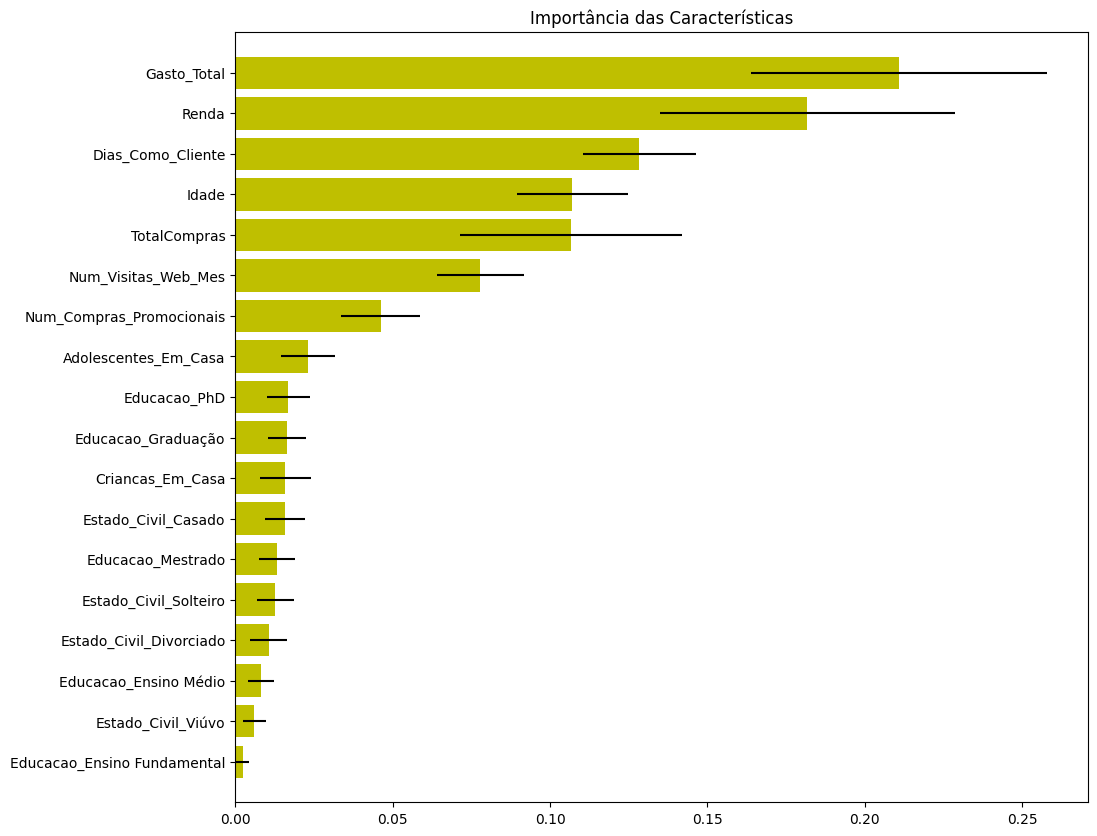

In [592]:
# Plot
plt.figure(1, figsize = (11, 10))
plt.title("Importância das Características")
plt.barh(range(X.shape[1]), importances[indices], color = "y", xerr = std[indices], align = "center")
plt.yticks(range(X.shape[1]), X.columns[indices])
plt.ylim([-1, X.shape[1]])
plt.show()

### Teste de Hipóteses

O nível educacional não parece ser relevante para explicar a resposta do cliente à campanha de Marketing. Por outro lado, Renda é bastante relevante. É provável que a média de renda seja diferente entre os níveis educacionais.

Testar a hipótese de que existe diferença significativa entre as médias de Renda dos clientes com Ensino Superior e sem Ensino Superior. Antes, vamos explorar essa relação.

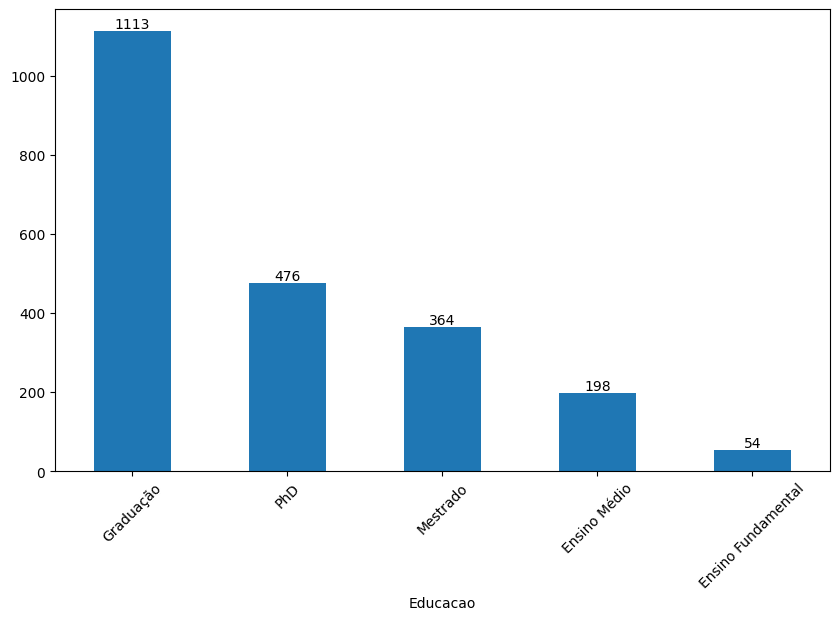

In [593]:
# Plot do total de clientes por nível educacional
plt.figure(figsize = (10, 6))
ax = df.Educacao.value_counts().plot.bar()
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.bar_label(ax.containers[0])
plt.show;

In [594]:
df.columns

Index(['ID', 'Educacao', 'Estado_Civil', 'Renda', 'Criancas_Em_Casa',
       'Adolescentes_Em_Casa', 'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes',
       'Gasto_Peixes', 'Gasto_Doces', 'Gasto_Outros',
       'Num_Compras_Promocionais', 'Num_Compras_Web', 'Num_Compras_Catalogo',
       'Num_Compras_Loja', 'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1',
       'Aceitou_Campanha_2', 'Aceitou_Campanha_3', 'Aceitou_Campanha_4',
       'Aceitou_Campanha_5', 'Aceitou_Campanha_6', 'Idade',
       'Dias_Como_Cliente', 'TotalCompras', 'Gasto_Total', 'RespostaCampanha'],
      dtype='object')

> Média de Renda Por Nível Educacional 

In [595]:
# Calcular a média
media_renda = df.groupby('Educacao')['Renda'].mean().reset_index()
media_renda = media_renda.sort_values(by = 'Renda')

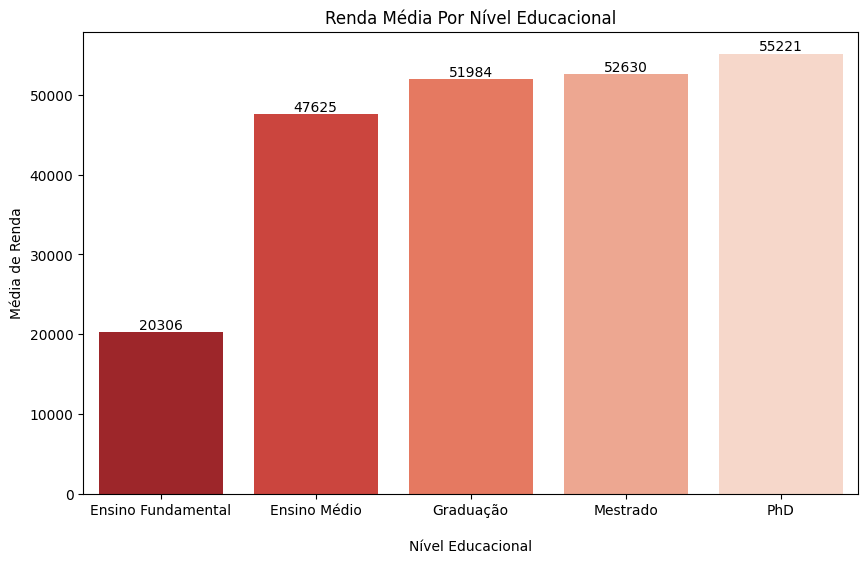

In [596]:
# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x = media_renda['Educacao'], y = media_renda['Renda'], data = df, palette = 'Reds_r')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha = 'center', 
                va = 'bottom')
plt.xlabel('\nNível Educacional')
plt.ylabel('Média de Renda')
plt.title('Renda Média Por Nível Educacional')
plt.show()

### Definindo as Hipóteses

Para escolher o Teste de Hipóteses precisamos verificar se as variáveis seguem ou não uma distribuição normal. Se as variáveis seguirem uma distribuição normal podemos usar um teste paramétrico. Caso contrário, devemos usar um teste não paramétrico.

**Hipótese Nula (H0)**: A hipótese nula é uma declaração de "não diferença". Em nosso caso, ela afirma que "Não há diferença significativa nas médias de renda de grupos com e sem nível superior". Isso significa que qualquer diferença observada nos dados entre os grupos pode ser atribuída ao acaso.

**Hipótese Alternativa (H1)**: A hipótese alternativa contrapõe a hipótese nula. Ela afirma que "Há uma diferença significativa nas médias de renda de grupos com e sem nível superior". Isso implica que as diferenças observadas são reais e não apenas resultado de variações aleatórias.

Quando você realiza um teste estatístico (como um teste t de Student para amostras independentes ou um teste não paramétrico como o Mann-Whitney U se as suposições do teste t não são atendidas), você está testando essas hipóteses. O resultado do teste (em especial, o valor-p) indica se você deve ou não rejeitar a hipótese nula:

**Valor-p Baixo (tipicamente < 0,05)**: Se o valor-p do teste for menor que o nível de significância escolhido (geralmente 0,05), você rejeita a hipótese nula, sugerindo que há evidências suficientes para afirmar que existe uma diferença significativa nas médias de renda entre os grupos.

**Valor-p Alto**: Se o valor-p for maior que o nível de significância, você não rejeita a hipótese nula, indicando que não há evidências suficientes para afirmar que existe uma diferença significativa.

É importante lembrar que "não rejeitar a hipótese nula" não é o mesmo que provar que a hipótese nula é verdadeira. Significa apenas que, com os dados disponíveis, não há evidências suficientes para apoiar a hipótese alternativa.

In [597]:
# Representação numérica da variável categórica
df['Educacao'] = df['Educacao'].map({'Ensino Fundamental':1,
                                             'Ensino Médio':2,
                                             'Graduação':3,
                                             'Mestrado':4,
                                             'PhD':5})

In [598]:
df.head()

,ID,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,...,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,RespostaCampanha
0,9970,3,Casado,55375.0,0,1,42,11,57,10,...,0,0,0,0,0,49,255,8,162,Não Aceitou
1,4002,5,Casado,77037.0,0,1,463,96,333,168,...,0,0,0,0,0,66,259,26,1123,Não Aceitou
2,10914,3,Solteiro,24163.0,1,1,4,1,7,2,...,0,0,0,0,0,56,1294,4,17,Não Aceitou
3,7279,5,Casado,69476.0,0,0,260,86,559,63,...,0,0,0,0,0,57,272,14,1044,Não Aceitou
4,10582,3,Casado,72063.0,0,1,180,32,348,76,...,0,0,0,0,0,47,2665,19,758,Não Aceitou


In [599]:
# Dados que serão testados
dados_para_testar = df[['Renda', 'Educacao']]

In [600]:
dados_para_testar.head()

,Renda,Educacao
0,55375.0,3
1,77037.0,5
2,24163.0,3
3,69476.0,5
4,72063.0,3


### Aplicando o Teste de Normalidade Para Selecionar o Teste de Hipóteses Adequado

O Teste de Shapiro-Wilk é utilizado para verificar se um conjunto de dados segue uma distribuição normal, sendo especialmente indicado para amostras pequenas.

Hipótese nula (H0): os dados seguem distribuição normal.

Hipótese alternativa (H1): os dados não seguem distribuição normal.

A decisão é baseada no valor-p:

p < 0,05: rejeita-se H0 → os dados não são normais.

p ≥ 0,05: não se rejeita H0 → não há evidência de que os dados não sejam normais.

O teste pode ser sensível ao tamanho da amostra: amostras muito grandes detectam pequenos desvios, enquanto amostras muito pequenas podem não detectar diferenças relevantes.

In [601]:
# Teste Shapiro-Wilk 
def dsa_testa_normal(columns):
    
    for column in columns:
        
        statistic, p_value = shapiro(dados_para_testar[column])

        alpha = 0.05
        
        if p_value < alpha:
             print(f'\n{column}: Alpha {alpha} < valor-p {p_value:.2f} - Rejeitamos a H0 do Teste Shapiro-Wilk: Os dados não são normalmente distribuídos.')
        else:
             print(f'\n{column}: Alpha {alpha} > valor-p {p_value:.2f} - Falhamos em Rejeitar a H0 do Teste Shapiro-Wilk: Os dados seguem uma distribuição normal.')

In [602]:
dsa_testa_normal(dados_para_testar)


Renda: Alpha 0.05 < valor-p 0.00 - Rejeitamos a H0 do Teste Shapiro-Wilk: Os dados não são normalmente distribuídos.

Educacao: Alpha 0.05 < valor-p 0.00 - Rejeitamos a H0 do Teste Shapiro-Wilk: Os dados não são normalmente distribuídos.


### Aplicando Teste de Hipóteses Não Paramétrico

O teste de Mann-Whitney U é utilizado para comparar dois grupos independentes quando os dados não seguem distribuição normal.

Ele é um teste não paramétrico e funciona como uma alternativa ao teste t de Student para amostras independentes, sendo aplicado quando as premissas do teste t não são atendidas.

In [603]:
# Criar os grupos
grupo_com_graduacao = df[df['Educacao'].isin([5, 4, 3])]['Renda']
grupo_sem_graduacao = df[df['Educacao'].isin([1, 2])]['Renda']

In [604]:
# Teste Mann-Whitney U 
statistic, p_value = mannwhitneyu(grupo_com_graduacao, grupo_sem_graduacao)

# Nível de significância
alpha = 0.05

# Resultado
if p_value < alpha:
    print("Rejeitamos a hipótese nula: Há uma diferença significativa nas médias de renda.")
else:
    print("Falhamos em rejeitar a hipótese nula: Não há diferença significativa nas médias de renda.")

Rejeitamos a hipótese nula: Há uma diferença significativa nas médias de renda.


### Conclusão

Os fatores que mais influenciam a resposta dos clientes às campanhas de marketing são histórico de gasto total, renda, tempo como cliente, idade e número de compras anteriores. Isso indica que clientes mais fiéis e com maior histórico de consumo têm maior probabilidade de responder às campanhas.

Inicialmente, nível educacional e estado civil não pareceram relevantes. No entanto, ao aplicar um teste de hipóteses, observou-se diferença significativa entre as médias de renda de clientes com e sem graduação, sendo a renda maior entre aqueles com níveis educacionais mais altos.

Assim, a empresa deve segmentar suas campanhas considerando principalmente renda e nível educacional, além de histórico de gastos, tempo de relacionamento, idade e número de compras.